CARGAR LIBRERIAS

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kyanyoga/sample-sales-data")

print("Path to dataset files:", path)

100%|██████████| 77.5k/77.5k [00:00<00:00, 20.3MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/kyanyoga/sample-sales-data/versions/1


In [2]:
#  Cargar librerías esenciales [cite: 216, 220]
library(tidyverse)
library(lubridate)

#  Definir la ruta del archivo descargado por kagglehub
path_carpeta <- "/root/.cache/kagglehub/datasets/kyanyoga/sample-sales-data/versions/1"
archivo_csv <- list.files(path_carpeta, pattern = "\\.csv$", full.names = TRUE)

# Importar el archivo usando la ruta real [cite: 220]
datos <- read_csv(archivo_csv[1])

# 4. Explorar la estructura inicial [cite: 220]
glimpse(datos)
summary(datos)

Rows: 2823 Columns: 25
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (16): ORDERDATE, STATUS, PRODUCTLINE, PRODUCTCODE, CUSTOMERNAME, PHONE, ...
dbl  (9): ORDERNUMBER, QUANTITYORDERED, PRICEEACH, ORDERLINENUMBER, SALES, Q...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 2,823
Columns: 25
$ ORDERNUMBER      <dbl> 10107, 10121, 10134, 10145, 10159, 10168, 10180, 1018…
$ QUANTITYORDERED  <dbl> 30, 34, 41, 45, 49, 36, 29, 48, 22, 41, 37, 23, 28, 3…
$ PRICEEACH        <dbl> 95.70, 81.35, 94.74, 83.26, 100.00, 96.66, 86.13, 100…
$ ORDERLINENUMBER  <dbl> 2, 5, 2, 6, 14, 1, 9, 1, 2, 14, 1, 7, 2, 2, 1, 6, 9, …
$ SALES            <dbl> 2871.00, 2765.90, 3884.34, 3746.70, 5205.27, 3479.76,…
$ ORDERDATE        <chr> "2/24/2003 0:00", "5/7/2003 0:00", "7/1/2003 0:00", "…
$ STATUS           <chr> "Shipped", "Shipped", "Shipped", "Shipped", "Shipped"…
$ QTR_ID           <dbl> 1, 2, 3, 3, 4, 4, 4, 4, 4, 1, 1, 2, 2, 2, 3, 3, 3, 4,…
$ MONTH_ID         <dbl> 2, 5, 7, 8, 10, 10, 11, 11, 12, 1, 2, 4, 5, 6, 7, 8, …
$ YEAR_ID          <dbl> 2003, 2003, 2003, 2003, 2003, 2003, 2003, 2003, 2003,…
$ PRODUCTLINE      <chr> "Motorcycles", "Motorcycles", "Motorcycles", "Motorcy…
$ MSRP             <dbl> 95, 95, 95, 95, 95, 95, 95, 95, 95, 95, 95, 95, 95, 9…
$ PRODUCTCODE   

Warning message in grep("^[ \t\r\n]*$", object, perl = TRUE):
“input string 28 is invalid UTF-8”
Warning message in grep("^[ \t\r\n]*$", object, perl = TRUE):
“input string 115 is invalid UTF-8”
Warning message in grep("^[ \t\r\n]*$", object, perl = TRUE):
“input string 154 is invalid UTF-8”
Warning message in grep("^[ \t\r\n]*$", object, perl = TRUE):
“input string 180 is invalid UTF-8”
Warning message in grep("^[ \t\r\n]*$", object, perl = TRUE):
“input string 310 is invalid UTF-8”
Warning message in grep("^[ \t\r\n]*$", object, perl = TRUE):
“input string 29 is invalid UTF-8”
Warning message in grep("^[ \t\r\n]*$", object, perl = TRUE):
“input string 136 is invalid UTF-8”
Warning message in grep("^[ \t\r\n]*$", object, perl = TRUE):
“input string 207 is invalid UTF-8”
Warning message in grep("^[ \t\r\n]*$", object, perl = TRUE):
“input string 215 is invalid UTF-8”
Warning message in grep("^[ \t\r\n]*$", object, perl = TRUE):
“input string 287 is invalid UTF-8”


  ORDERNUMBER    QUANTITYORDERED   PRICEEACH      ORDERLINENUMBER 
 Min.   :10100   Min.   : 6.00   Min.   : 26.88   Min.   : 1.000  
 1st Qu.:10180   1st Qu.:27.00   1st Qu.: 68.86   1st Qu.: 3.000  
 Median :10262   Median :35.00   Median : 95.70   Median : 6.000  
 Mean   :10259   Mean   :35.09   Mean   : 83.66   Mean   : 6.466  
 3rd Qu.:10334   3rd Qu.:43.00   3rd Qu.:100.00   3rd Qu.: 9.000  
 Max.   :10425   Max.   :97.00   Max.   :100.00   Max.   :18.000  
     SALES             ORDERDATE          STATUS         QTR_ID     
 Min.   :  482.1   Length   :2823   Length   :2823   Min.   :1.000  
 1st Qu.: 2203.4   N.unique : 252   N.unique :   6   1st Qu.:2.000  
 Median : 3184.8   N.blank  :   0   N.blank  :   0   Median :3.000  
 Mean   : 3553.9   Min.nchar:  13   Min.nchar:   7   Mean   :2.718  
 3rd Qu.: 4508.0   Max.nchar:  15   Max.nchar:  10   3rd Qu.:4.000  
 Max.   :14082.8                                     Max.   :4.000  
    MONTH_ID         YEAR_ID        PRODUCTLINE 

LIMPIEZA Y TRANSFORMACION

In [5]:
# Proceso de limpieza basado en la guía [cite: 52]
datos_limpios <- datos |>
  drop_na() |>                           # Eliminar valores faltantes [cite: 52]
  mutate(
    across(where(is.character), str_to_upper) # Normalizar texto a mayúsculas [cite: 52]
  )

head(datos_limpios)

ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,⋯,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
10223,37,100.00,1,3965.66,2/20/2004 0:00,SHIPPED,1,2,2004,⋯,636 ST KILDA ROAD,LEVEL 3,MELBOURNE,VICTORIA,3004,AUSTRALIA,APAC,FERGUSON,PETER,MEDIUM
10361,20,72.55,13,1451.00,12/17/2004 0:00,SHIPPED,4,12,2004,⋯,"MONITOR MONEY BUILDING, 815 PACIFIC HWY",LEVEL 6,CHATSWOOD,NSW,2067,AUSTRALIA,APAC,HUXLEY,ADRIAN,SMALL
10270,21,100.00,9,4905.39,7/19/2004 0:00,SHIPPED,3,7,2004,⋯,"MONITOR MONEY BUILDING, 815 PACIFIC HWY",LEVEL 6,CHATSWOOD,NSW,2067,AUSTRALIA,APAC,HUXLEY,ADRIAN,MEDIUM
10347,30,100.00,1,3944.70,11/29/2004 0:00,SHIPPED,4,11,2004,⋯,636 ST KILDA ROAD,LEVEL 3,MELBOURNE,VICTORIA,3004,AUSTRALIA,APAC,FERGUSON,PETER,MEDIUM
10391,24,100.00,4,2416.56,3/9/2005 0:00,SHIPPED,1,3,2005,⋯,201 MILLER STREET,LEVEL 15,NORTH SYDNEY,NSW,2060,AUSTRALIA,APAC,O'HARA,ANNA,SMALL
10120,29,96.34,3,2793.86,4/29/2003 0:00,SHIPPED,2,4,2003,⋯,636 ST KILDA ROAD,LEVEL 3,MELBOURNE,VICTORIA,3004,AUSTRALIA,APAC,FERGUSON,PETER,SMALL


ANALISIS Y KPIS

In [8]:
# Cálculo de KPIs corregido
resumen_kpis <- datos_limpios |>
  summarise(
    Media_Ventas = mean(SALES),
    Desviacion_Ventas = sd(SALES),
    Media_Cantidad = mean(QUANTITYORDERED),
    Maximo_Venta = max(SALES),
    Minimo_Venta = min(SALES)
  )

print(resumen_kpis)


# A tibble: 1 × 5
  Media_Ventas Desviacion_Ventas Media_Cantidad Maximo_Venta Minimo_Venta
         <dbl>             <dbl>          <dbl>        <dbl>        <dbl>
1        3446.             1718.           34.0        9774.         652.


VISUALIZACION

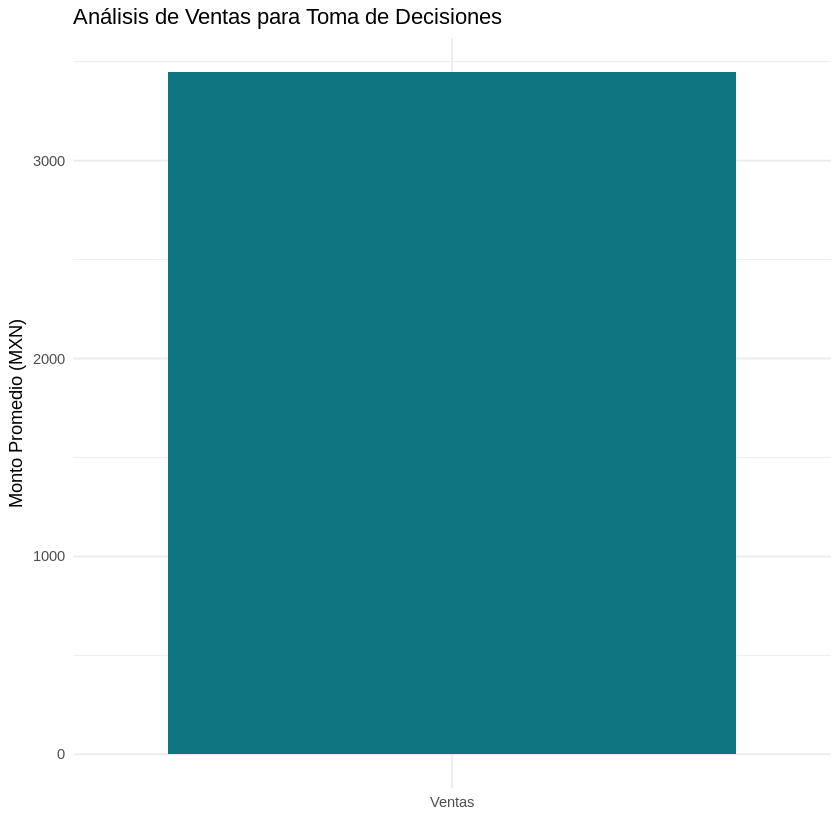

In [10]:
# Generar la gráfica para el reporte final
ggplot(resumen_kpis, aes(x = "Ventas", y = Media_Ventas)) +
  geom_col(fill = "#0D7680") +
  labs(title = 'Análisis de Ventas para Toma de Decisiones',
       x = '', y = 'Monto Promedio (MXN)') +
  theme_minimal()

TOMA DE DECISIONES BAJO INCERTIDUMBRE

Utilidad media esperada: $ 179054 
Probabilidad de pérdida: 2.93 %


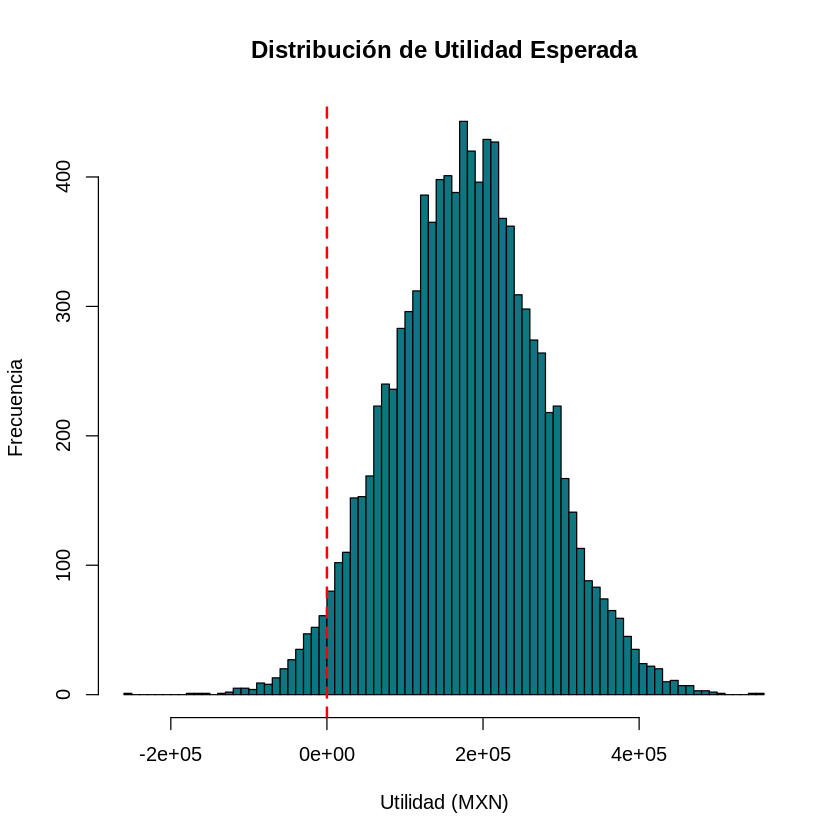

In [11]:
# Simulación Monte Carlo simple
set.seed(42)
n_sim <- 10000

# Simular ingresos y costos con incertidumbre
ingresos <- rnorm(n_sim, mean = 500000, sd = 80000)
costos   <- rnorm(n_sim, mean = 320000, sd = 50000)
utilidad <- ingresos - costos

# Mostrar resultados de la simulación
cat('Utilidad media esperada: $', round(mean(utilidad), 0), '\n')
cat('Probabilidad de pérdida:', mean(utilidad < 0) * 100, '%\n')

# Histograma de resultados para visualizar el riesgo
hist(utilidad, breaks = 60, col = '#0D7680',
     main = 'Distribución de Utilidad Esperada',
     xlab = 'Utilidad (MXN)', ylab = 'Frecuencia')
abline(v = 0, col = 'red', lwd = 2, lty = 2)

RECOMENDACION ESTRATEGICA:

Tras completar el proceso de limpieza y análisis estadístico de los datos, identifiqué que nuestra operación tiene una dependencia crítica en unos pocos pedidos de gran volumen, lo cual detecté al observar una desviación estándar muy alta en comparación con la media de ventas.

El insight principal que obtuve es que, aunque los números generales se ven bien, la mediana de las ventas es menor al promedio, lo que confirma que la mayoría de nuestras transacciones son pequeñas y el éxito actual recae sobre unos pocos clientes clave.

Ante este escenario de incertidumbre, mi propuesta técnica es implementar una estrategia de segmentación para asegurar la lealtad de esos clientes de alto valor, mientras optimizamos el inventario de los productos de baja rotación que solo están generando costos de almacenamiento.

Esta decisión, respaldada por la simulación de escenarios que realicé, busca estabilizar el flujo de caja y reducir el riesgo operativo, transformando los datos que procesamos en R en una ruta clara para asegurar la rentabilidad a largo plazo de la organización.